# BarrierNet vs Amortized NMPC

Two trained approximations of the same NMPC oracle, same vessel, same data, same safety
filter — they differ only in what the network predicts:

| file | class | network predicts | QP solved |
|---|---|---|---|
| `anmpc_alpha/model.eqx` (`ana_i64`) | `AmortizedNMPCAlpha` | a residual on the QP objective `(H, c)` + class-K gains | `min ½ uᵀH u + cᵀu` s.t. box + HOCBF |
| `barriernet/model.eqx` (`i64`) | `BarrierNet` | a nominal command `u_nom` + class-K gains | `min ½‖u − u_nom‖²` s.t. box + HOCBF |

Both are safe by construction. This notebook loads both, runs one step, and compares one
closed-loop rollout. Everything in `anmpc_alpha/INTEGRATION.md` applies to both.

## Load

In [1]:
import time

import numpy as np
import jax.numpy as jnp
import equinox as eqx
import matplotlib.pyplot as plt

# The anmpc_alpha/barriernet *packages* only re-export a narrow public surface
# (loader + shared plant utils); stage_residual is private to the anmpc_alpha
# implementation submodule, so pull everything from there directly.
from anmpc_alpha.anmpc_alpha import (
    load_alpha_model, make_env, stage_residual,
    rk4_step_numpy, wrap_angle, anchor_arc_length,
)
from barriernet import load_barriernet_model

amortized, dtype = load_alpha_model("anmpc_alpha/model.eqx", meta_path="anmpc_alpha/model_meta.yaml")
barrier, _       = load_barriernet_model("barriernet/model.eqx",
                                         meta_path="barriernet/model_meta.yaml")
env = make_env(n_obs=amortized.n_obs, dt=amortized.dt)

print(f"n_obs = {env.n_obs}, dt = {env.dt} s, r_ego = {env.r_ego:.3f} m")
print(type(amortized).__name__, "|", type(barrier).__name__)

No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


n_obs = 6, dt = 0.1 s, r_ego = 0.503 m
AmortizedNMPCAlpha | BarrierNet


## One step

Same signature for both: `model(x, path, obs_centers, obs_radii) -> (u_safe, u_nom, gammas)`.
For BarrierNet `u_nom` is the network's unfiltered command, so `‖u_safe − u_nom‖` is how
much the QP intervened; for the amortized model it is a zero placeholder.

In [2]:
@eqx.filter_jit
def step(model, x, path, oc, orr):
    return model(x, path, oc, orr)


kx, y0, u_ref = 0.2, 3.0, 0.55
path = np.array([kx, y0, u_ref])

X_obs = np.array([5.0, 10.0, 15.0, 20.0, 25.0, 30.0])
lat   = 0.2 * np.array([1, -1, 1, -1, 1, -1])
obs_centers = np.stack([X_obs, np.sin(X_obs) + y0 + lat], axis=1)
obs_radii   = np.full(env.n_obs, 0.6)

# starts at rest (su=0): qs_sim_node/Sim.cpp never sets an initial
# velocity from any rosparam, so the real ROS plant always starts at 0
x0 = np.array([0.0, y0, np.arctan2(np.cos(0.0), 1.0), 0.3, 0.0, 0.0, 0.0])
x0[6] = anchor_arc_length(path, x0, 0.0)

x_j    = jnp.asarray(x0, dtype)
path_j = jnp.asarray(path, dtype)
oc_j   = jnp.asarray(obs_centers, dtype)
or_j   = jnp.asarray(obs_radii, dtype)

for name, model in [("barriernet", barrier), ("amortized", amortized)]:
    u_safe, u_nom, gammas = step(model, x_j, path_j, oc_j, or_j)
    u_safe = np.asarray(u_safe)
    u_nom  = np.asarray(u_nom)
    gammas = np.asarray(gammas)

    gap = (f"{np.linalg.norm(u_safe - u_nom):.1e} N" if name == "barriernet"
           else "n/a (u_nom is a placeholder)")
    print(f"{name:>10} | u_safe {np.array2string(u_safe, precision=3):<30} "
          f"| gamma1 {np.array2string(gammas[:2, 0], precision=2)} "
          f"| intervention {gap}")

barriernet | u_safe [ 2.971  2.79   0.348 -0.018]  | gamma1 [0.5 0.5] | intervention 8.7e-13 N
 amortized | u_safe [ 2.655  2.82  -0.303  0.027]  | gamma1 [0.5 0.5] | intervention n/a (u_nom is a placeholder)


## Closed loop

Same start, same path, same six obstacles, same plant. We accumulate the stage cost the
oracle minimizes, `Σ_t ‖r(x_t)‖² + r_f‖u_t‖²`.

In [3]:
Q_STATE, R_F = (20.0, 0.1, 10.0, 200.0), 1.0


def rollout(model, n_steps=400):
    pj, cj, rj = (jnp.asarray(path, dtype), jnp.asarray(obs_centers, dtype),
                  jnp.asarray(obs_radii, dtype))
    step(model, jnp.asarray(x0, dtype), pj, cj, rj)          # warm up the JIT

    x = x0.copy()
    states, us, costs, times = [x.copy()], [], [], []
    for _ in range(n_steps):
        x[6] = anchor_arc_length(path, x, x[6])
        t0 = time.perf_counter()
        u = np.asarray(step(model, jnp.asarray(x, dtype), pj, cj, rj)[0], float)
        times.append(time.perf_counter() - t0)

        r = np.asarray(stage_residual(jnp.asarray(x), jnp.asarray(path), Q_STATE))
        costs.append(float(r @ r + R_F * np.dot(u, u)))
        us.append(u)

        x = rk4_step_numpy(x, u, env.dt)
        x[2] = wrap_angle(x[2])
        x[6] = anchor_arc_length(path, x, x[6])
        states.append(x.copy())

    states, us = np.array(states), np.array(us)
    return dict(
        states=states, cost_trace=np.array(costs), cost=float(np.sum(costs)),
        min_clear=min(np.linalg.norm(s[:2] - c) - (r + env.r_ego)
                      for s in states for c, r in zip(obs_centers, obs_radii)),
        effort=float(np.sqrt(np.mean(np.sum(us ** 2, axis=1)))),
        t_ms=float(np.mean(times[1:]) * 1e3),
    )


runs = {"barriernet": rollout(barrier), "amortized": rollout(amortized)}

rows = [("closed-loop cost", "{:.0f}", "cost"),
        ("min clearance [m]", "{:.3f}", "min_clear"),
        ("control effort RMS [N]", "{:.2f}", "effort"),
        ("solve time [ms]", "{:.2f}", "t_ms")]
head = f"{'':<24}" + "".join(f"{n:>14}" for n in runs)
print(head); print("-" * len(head))
for label, fmt, key in rows:
    print(f"{label:<24}" + "".join(f"{fmt.format(r[key]):>14}" for r in runs.values()))
print(f"\ncost ratio: {runs['barriernet']['cost'] / runs['amortized']['cost']:.2f}x")

                            barriernet     amortized
----------------------------------------------------
closed-loop cost                  8350          6465
min clearance [m]                0.052         0.038
control effort RMS [N]            2.28          2.29
solve time [ms]                   0.58          0.72

cost ratio: 1.29x


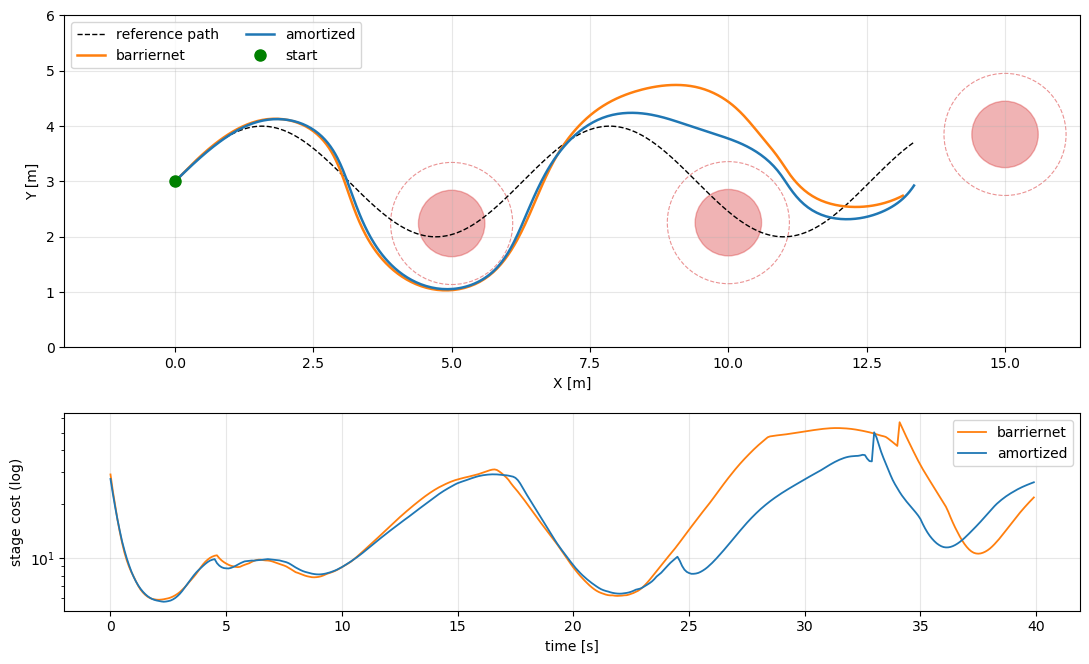

In [4]:
colors = {"barriernet": "tab:orange", "amortized": "tab:blue"}
fig, (ax, ax2) = plt.subplots(2, 1, figsize=(11, 7),
                              gridspec_kw=dict(height_ratios=[2, 1]))

s_grid = np.linspace(0, max(r["states"][:, 6].max() for r in runs.values()) + 2, 600)
ax.plot(kx * s_grid, np.sin(kx * s_grid) + y0, "k--", lw=1, label="reference path")
for name, r in runs.items():
    ax.plot(r["states"][:, 0], r["states"][:, 1], lw=1.8, color=colors[name], label=name)
ax.plot(x0[0], x0[1], "go", ms=8, label="start")
for c, rr in zip(obs_centers, obs_radii):
    ax.add_patch(plt.Circle(c, rr, color="tab:red", alpha=0.35))
    ax.add_patch(plt.Circle(c, rr + env.r_ego, color="tab:red", alpha=0.5,
                            ls="--", lw=0.8, fill=False))
ax.set_xlim(-2.0, max(r["states"][:, 0].max() for r in runs.values()) + 3.0)
ax.set_ylim(y0 - 3.0, y0 + 3.0)
ax.set_aspect("equal"); ax.grid(alpha=0.3); ax.legend(loc="upper left", ncol=2)
ax.set_xlabel("X [m]"); ax.set_ylabel("Y [m]")

t = np.arange(len(runs["amortized"]["cost_trace"])) * env.dt
for name, r in runs.items():
    ax2.plot(t, r["cost_trace"], lw=1.3, color=colors[name], label=name)
ax2.set_yscale("log"); ax2.grid(alpha=0.3); ax2.legend()
ax2.set_xlabel("time [s]"); ax2.set_ylabel("stage cost (log)")

fig.tight_layout()
plt.show()

## Takeaway

Swapping between the models is one line:

```python
from barriernet import load_barriernet_model
model, dtype = load_barriernet_model("barriernet/model.eqx",
                                     meta_path="barriernet/model_meta.yaml")
u_safe, u_nom, gammas = model(x, path, obs_centers, obs_radii)
```

To compare either against the oracle itself, see `mpc_oracle.py` (needs CasADi).

This is exactly what `barriernet_node.py` / `anmpc_alpha_node.py` do in the ROS package
(see `control/launch/barriernet_test.launch` and `ampc_alpha_test.launch`), so numbers
from this notebook should match what those nodes report on `/mpc_status_barriernet` and
`/mpc_status_alpha`.